# Distribution Transformations

Many real-world features are heavily right-skewed — income, house prices, population counts, transaction amounts. Linear models and algorithms that assume Gaussian inputs (PCA, LDA, certain regularisers) perform poorly on such data. Transforming skewed features toward normality often unlocks significant performance gains.

### What you will learn

| Section | Transformation | Best when |
|---------|---------------|----------|
| 1 | Diagnosing skewness | Always — before choosing a transform |
| 2 | Log transformation | Positive values; known power-law distribution |
| 3 | Square-root transformation | Count data; moderate right skew |
| 4 | Box-Cox transformation | Positive values; automatic power selection |
| 5 | Yeo-Johnson transformation | Positive *and* negative values; most flexible |
| 6 | Quantile transformation | Any distribution → Gaussian or uniform |
| 7 | Comparing all methods on model performance | |

**Dataset:** California Housing + synthetic heavy-tailed data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    PowerTransformer, QuantileTransformer, FunctionTransformer
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, train_test_split
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')

Setup complete.


In [2]:
# Load California Housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# Generate synthetic heavy-tailed features to showcase transformations clearly
rng = np.random.default_rng(42)
n = 5000

df_synth = pd.DataFrame({
    'income'       : np.exp(rng.normal(10.5, 1.0, n)),   # log-normal (strong right skew)
    'page_views'   : rng.negative_binomial(5, 0.1, n).astype(float),  # count data, heavy tail
    'temperature'  : rng.normal(20, 5, n),               # roughly normal — control case
    'response_time': rng.exponential(scale=200, size=n), # exponential distribution
})

print('Synthetic dataset shape:', df_synth.shape)
df_synth.describe().round(2)

Synthetic dataset shape: (5000, 4)


,income,page_views,temperature,response_time
count,5000.00,5000.00,5000.00,5000.00
mean,58752.86,45.35,19.99,200.98
std,76109.34,21.12,5.03,199.40
min,945.38,2.00,-1.29,0.01
25%,18179.43,30.00,16.57,57.55
50%,36164.71,42.00,20.01,141.42
75%,68271.48,58.00,23.37,275.20
max,1148590.85,179.00,38.41,1553.30


---
## Section 1 — Diagnosing Skewness

Before choosing a transformation, measure and visualise the skewness of each feature.

| Skewness range | Interpretation | Action |
|---------------|---------------|--------|
| −0.5 to +0.5 | Approximately symmetric | Usually no transformation needed |
| ±0.5 to ±1.0 | Moderate skew | Consider transformation |
| > ±1.0 | Strong skew | Transformation likely beneficial |

**Tools:** `scipy.stats.skew`, `scipy.stats.probplot` (Q-Q plot against normal).

In [3]:
# Compute skewness for all synthetic features
for col in df_synth.columns:
    sk = df_synth[col].skew()
    kurt = df_synth[col].kurtosis()
    print(f'{col:15s}  skewness={sk:+.2f}  kurtosis={kurt:+.2f}')

income           skewness=+4.54  kurtosis=+33.04
page_views       skewness=+0.89  kurtosis=+1.34
temperature      skewness=+0.00  kurtosis=+0.00
response_time    skewness=+1.89  kurtosis=+4.85


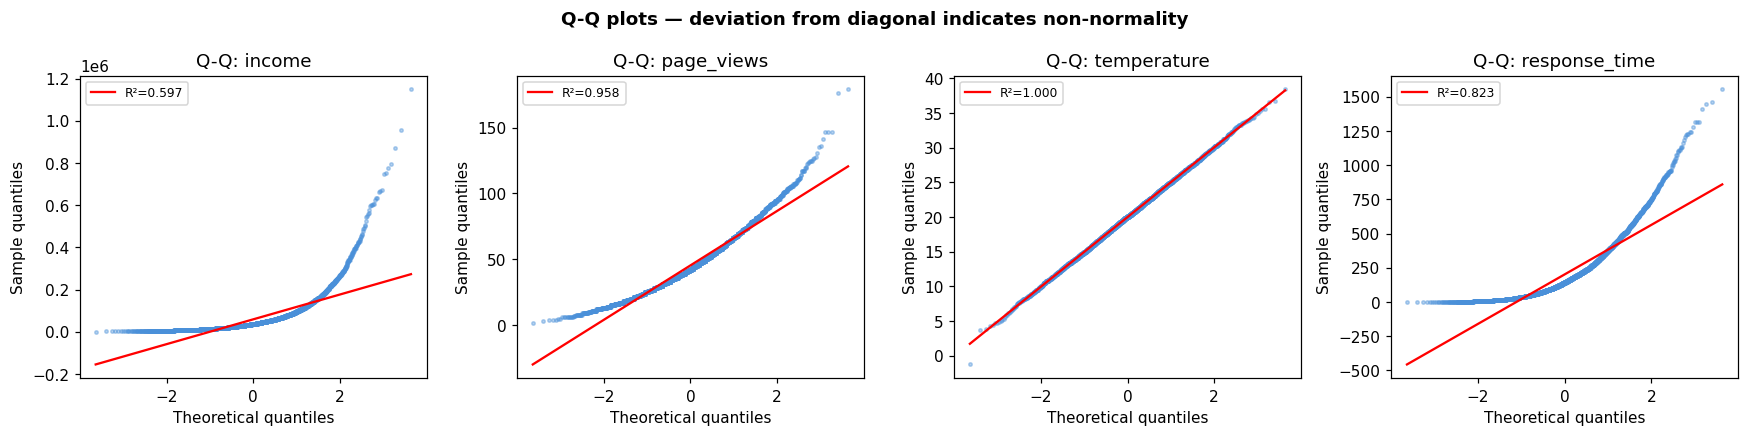

In [4]:
# Q-Q plots: deviation from the diagonal = deviation from normality
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, df_synth.columns):
    (osm, osr), (slope, intercept, r) = stats.probplot(df_synth[col], dist='norm')
    ax.scatter(osm, osr, s=5, alpha=0.4, color='#4a90d9')
    ax.plot([osm.min(), osm.max()],
            [slope * osm.min() + intercept, slope * osm.max() + intercept],
            color='red', linewidth=1.5, label=f'R²={r**2:.3f}')
    ax.set_title(f'Q-Q: {col}')
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Sample quantiles')
    ax.legend(fontsize=8)

plt.suptitle('Q-Q plots — deviation from diagonal indicates non-normality', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2 — Log Transformation

The most common transformation for right-skewed, strictly positive data:

```
x' = log(x)          # natural log
x' = log1p(x)        # log(1+x) — safe when x can be 0
```

**Why it works:** Compresses the long right tail; stretches the left tail. Ideal for data that follows a **power law** (incomes, prices, city populations).

**Requirements:** All values must be strictly positive. Use `log1p` when zeros are possible.

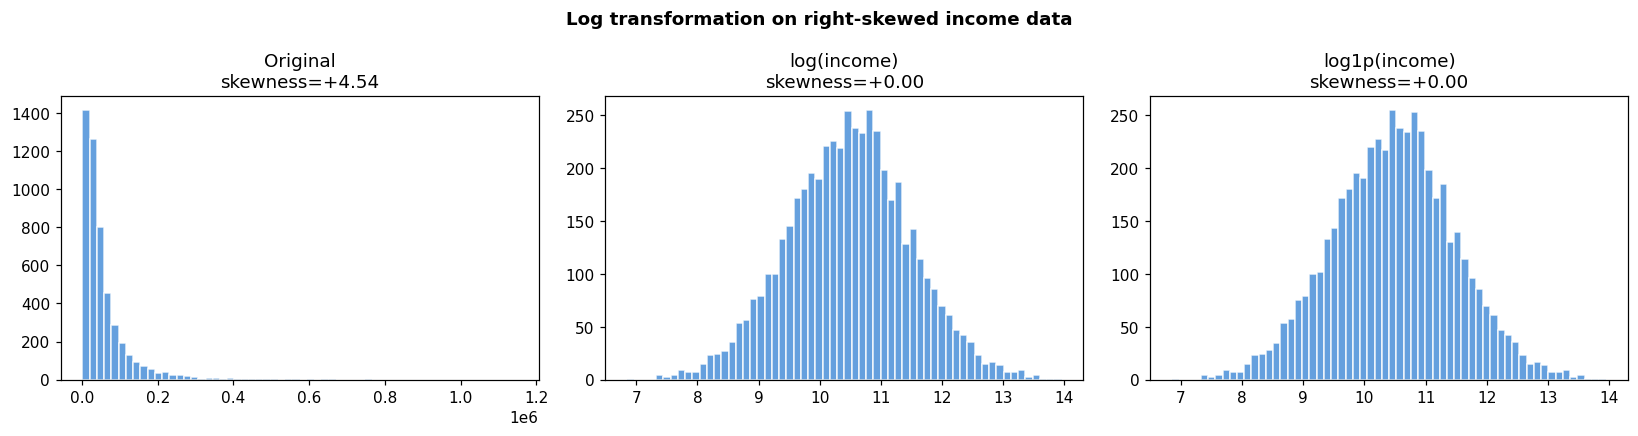

In [5]:
income = df_synth['income'].copy()

log_income = np.log(income)        # natural log (safe: all values > 0)
log1p_income = np.log1p(income)    # equivalent here; safer in general

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title in [
    (axes[0], income,     f'Original\nskewness={income.skew():+.2f}'),
    (axes[1], log_income, f'log(income)\nskewness={log_income.skew():+.2f}'),
    (axes[2], log1p_income, f'log1p(income)\nskewness={log1p_income.skew():+.2f}'),
]:
    ax.hist(data, bins=60, color='#4a90d9', edgecolor='white', alpha=0.85)
    ax.set_title(title)

plt.suptitle('Log transformation on right-skewed income data', fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Log via sklearn FunctionTransformer — integrates into Pipelines
log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=True)

sample = income.values[:5].reshape(-1, 1)
transformed = log_transformer.transform(sample)
reconstructed = log_transformer.inverse_transform(transformed)

print('Original → log1p → expm1 (round-trip):')
for o, t, r in zip(sample.ravel(), transformed.ravel(), reconstructed.ravel()):
    print(f'  {o:12.2f}  →  {t:.4f}  →  {r:.2f}')

Original → log1p → expm1 (round-trip):
      49252.58  →  10.8047  →  49252.58
      12836.09  →  9.4601  →  12836.09
      76914.62  →  11.2505  →  76914.62
      93019.53  →  11.4406  →  93019.53
       5161.41  →  8.5492  →  5161.41


---
## Section 3 — Square-Root Transformation

```
x' = √x
```

Milder than log — useful for **count data** and **moderate right skew**. Works for zero values (unlike log). Does not work on negative values.

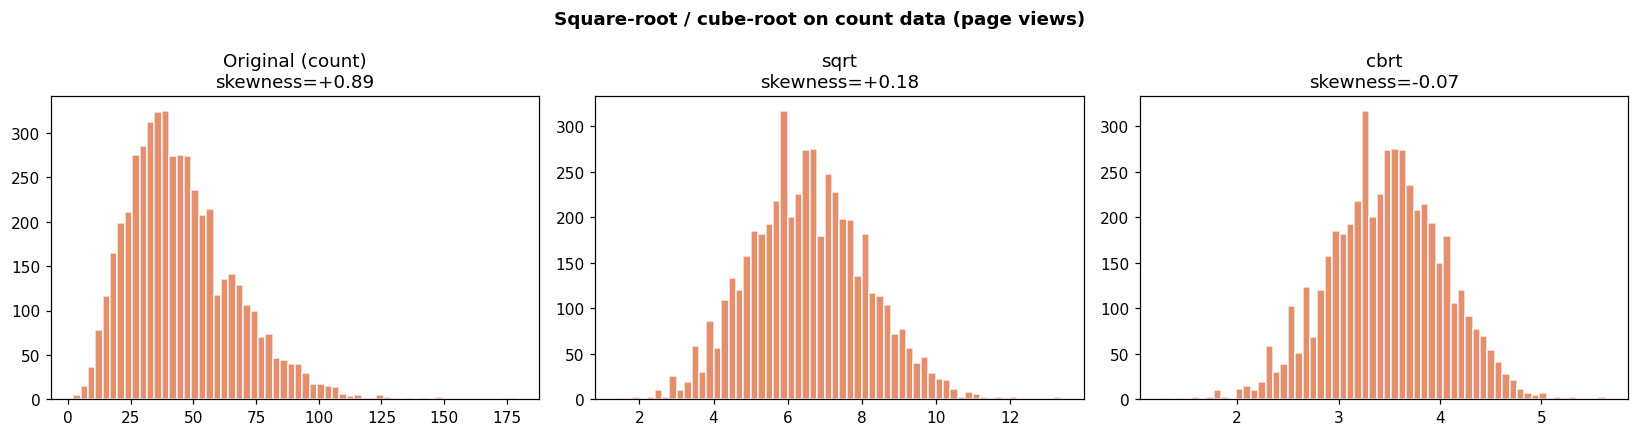

In [7]:
page_views = df_synth['page_views'].copy()

sqrt_views = np.sqrt(page_views)
cbrt_views  = np.cbrt(page_views)  # cube root — even milder, handles negatives

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in [
    (axes[0], page_views, f'Original (count)\nskewness={page_views.skew():+.2f}'),
    (axes[1], sqrt_views, f'sqrt\nskewness={sqrt_views.skew():+.2f}'),
    (axes[2], cbrt_views, f'cbrt\nskewness={cbrt_views.skew():+.2f}'),
]:
    ax.hist(data, bins=60, color='#e07b54', edgecolor='white', alpha=0.85)
    ax.set_title(title)

plt.suptitle('Square-root / cube-root on count data (page views)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4 — Box-Cox Transformation

Box-Cox finds the **optimal power λ** that makes the data most Gaussian:

```
x' = (x^λ − 1) / λ   if λ ≠ 0
x' = log(x)           if λ = 0
```

Special cases: λ=0 → log; λ=0.5 → sqrt; λ=1 → no change; λ=−1 → reciprocal.

**Requirement:** All values must be strictly positive.  
**Advantage over manual log/sqrt:** λ is chosen by maximum likelihood — no guessing.

Optimal Box-Cox λ: 0.2709
Original skewness  : +1.8849
Transformed skewness: -0.0440


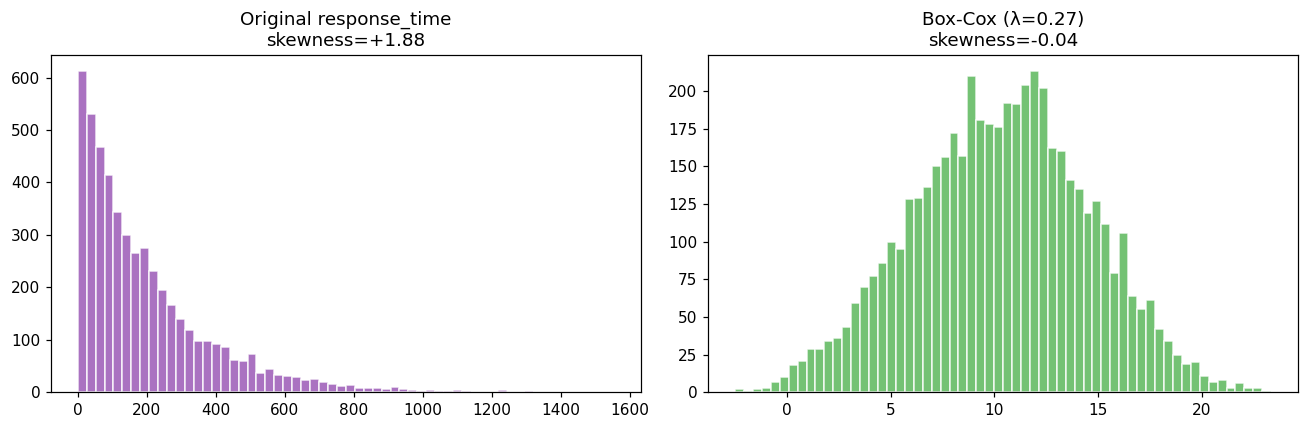

In [8]:
# scipy implementation for a single array
response = df_synth['response_time'].values

bc_transformed, lambda_val = stats.boxcox(response + 0.01)  # +0.01 to ensure positivity

print(f'Optimal Box-Cox λ: {lambda_val:.4f}')
print(f'Original skewness  : {stats.skew(response):+.4f}')
print(f'Transformed skewness: {stats.skew(bc_transformed):+.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(response,        bins=60, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Original response_time\nskewness={stats.skew(response):+.2f}')
axes[1].hist(bc_transformed,  bins=60, color='#5cb85c', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Box-Cox (λ={lambda_val:.2f})\nskewness={stats.skew(bc_transformed):+.2f}')
plt.tight_layout()
plt.show()

In [9]:
# sklearn PowerTransformer — integrates into Pipelines, handles multiple columns
pt_boxcox = PowerTransformer(method='box-cox', standardize=True)

# Requires strictly positive values
X_pos = df_synth[['income', 'page_views', 'response_time']].clip(lower=0.01)
X_bc = pd.DataFrame(
    pt_boxcox.fit_transform(X_pos),
    columns=X_pos.columns
)

print('Box-Cox lambdas per column:')
for col, lam in zip(X_pos.columns, pt_boxcox.lambdas_):
    print(f'  {col:15s}  λ = {lam:.4f}')

print('\nSkewness after Box-Cox:')
for col in X_bc.columns:
    print(f'  {col:15s}  {X_bc[col].skew():+.4f}')

Box-Cox lambdas per column:
  income           λ = -0.0007
  page_views       λ = 0.3810
  response_time    λ = 0.2713

Skewness after Box-Cox:
  income           -0.0000
  page_views       +0.0008
  response_time    -0.0438


---
## Section 5 — Yeo-Johnson Transformation

Yeo-Johnson is a generalisation of Box-Cox that **works on zero and negative values**:

```
x' = ((x+1)^λ − 1) / λ               if λ ≠ 0, x ≥ 0
x' = log(x+1)                         if λ = 0, x ≥ 0
x' = −((−x+1)^(2−λ) − 1) / (2−λ)    if λ ≠ 2, x < 0
x' = −log(−x+1)                       if λ = 2, x < 0
```

**Prefer Yeo-Johnson** in general — it's a strict superset of Box-Cox and never fails due to non-positive values.

In [10]:
# Yeo-Johnson works on all columns — no positivity constraint
pt_yj = PowerTransformer(method='yeo-johnson', standardize=True)
X_yj = pd.DataFrame(
    pt_yj.fit_transform(df_synth),
    columns=df_synth.columns
)

print('Yeo-Johnson results:')
for col in df_synth.columns:
    before = df_synth[col].skew()
    after  = X_yj[col].skew()
    print(f'  {col:15s}  {before:+.2f}  →  {after:+.2f}')

Yeo-Johnson results:
  income           +4.54  →  -0.00
  page_views       +0.89  →  -0.00
  temperature      +0.00  →  +0.00
  response_time    +1.89  →  -0.05


---
## Section 6 — Quantile Transformation

Quantile transformation maps the feature distribution to a **uniform or Gaussian distribution** by rank:
- Each value is replaced by its quantile rank
- Non-parametric — makes no assumptions about the original distribution
- Completely eliminates the impact of outliers (they become the boundary quantiles)

**Trade-off:** Loses some ordinality information — the exact values are discarded, only ranks survive. Use when normality is mandatory and the exact value differences are not meaningful.

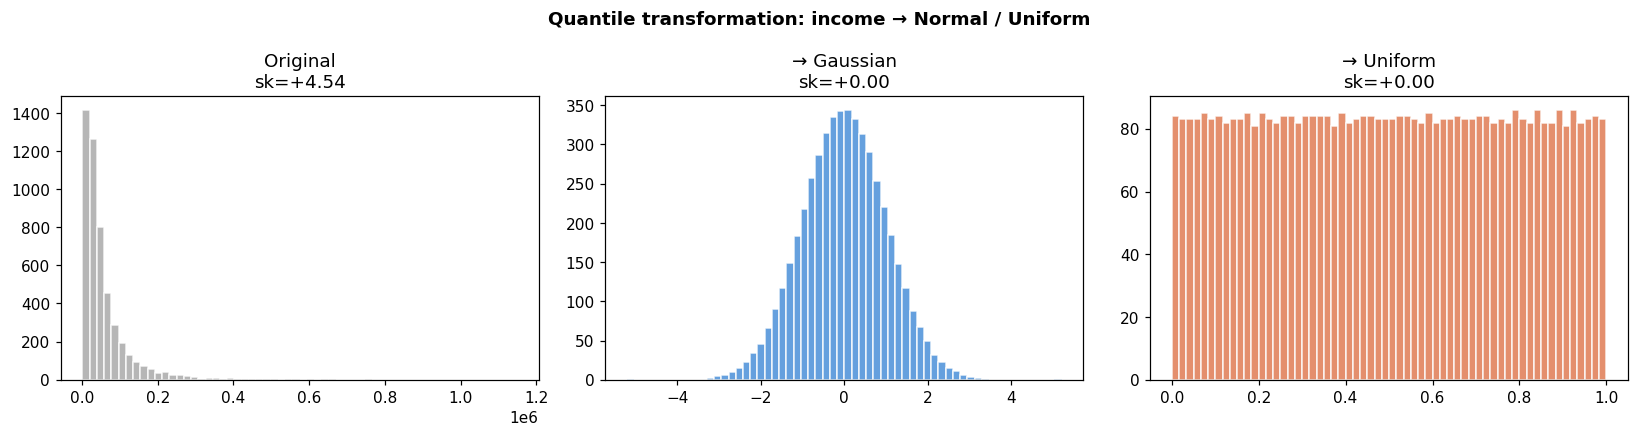

In [11]:
qt_normal  = QuantileTransformer(output_distribution='normal',  random_state=42)
qt_uniform = QuantileTransformer(output_distribution='uniform', random_state=42)

income_arr = df_synth[['income']].values
X_qt_norm = qt_normal.fit_transform(income_arr)
X_qt_unif = qt_uniform.fit_transform(income_arr)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title, color in [
    (axes[0], income_arr.ravel(), f'Original\nsk={stats.skew(income_arr.ravel()):+.2f}', '#aaaaaa'),
    (axes[1], X_qt_norm.ravel(),  f'→ Gaussian\nsk={stats.skew(X_qt_norm.ravel()):+.2f}', '#4a90d9'),
    (axes[2], X_qt_unif.ravel(),  f'→ Uniform\nsk={stats.skew(X_qt_unif.ravel()):+.2f}', '#e07b54'),
]:
    ax.hist(data, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)

plt.suptitle('Quantile transformation: income → Normal / Uniform', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 7 — Comparing All Methods on Model Performance

In [12]:
# Use California Housing numeric features to predict house prices.
# Latitude and Longitude are excluded: geographic coordinates are negative
# and should not be monotonically transformed — they encode spatial position, not magnitude.

def clip_positive(X):
    """Clip to a small positive floor so Box-Cox never receives zeros or negatives."""
    return np.clip(X, 0.01, None)

positive_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
X_housing = df[positive_features].copy()
y_housing  = df['MedHouseVal'].copy()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

strategies = {
    'No transform'      : Pipeline([('model', Ridge())]),
    'Log1p'             : Pipeline([
        ('log',   FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=True)),
        ('model', Ridge()),
    ]),
    'Box-Cox'           : Pipeline([
        ('clip',  FunctionTransformer(clip_positive, validate=True)),
        ('bc',    PowerTransformer(method='box-cox')),
        ('model', Ridge()),
    ]),
    'Yeo-Johnson'       : Pipeline([
        ('yj',    PowerTransformer(method='yeo-johnson')),
        ('model', Ridge()),
    ]),
    'Quantile → Normal' : Pipeline([
        ('qt',    QuantileTransformer(output_distribution='normal', random_state=42)),
        ('model', Ridge()),
    ]),
}

print('Strategy comparison (5-fold CV R², Ridge regression):')
results = {}
for name, pipe in strategies.items():
    scores = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring='r2')
    results[name] = scores
    print(f'  {name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

Strategy comparison (5-fold CV R², Ridge regression):
  No transform               mean=0.5422  std=0.0123
  Log1p                      mean=0.5690  std=0.0105
  Box-Cox                    mean=0.5692  std=0.0074
  Yeo-Johnson                mean=0.5715  std=0.0076
  Quantile → Normal          mean=0.5572  std=0.0052


  Yeo-Johnson                mean=0.5715  std=0.0076
  Quantile → Normal          mean=0.5572  std=0.0052


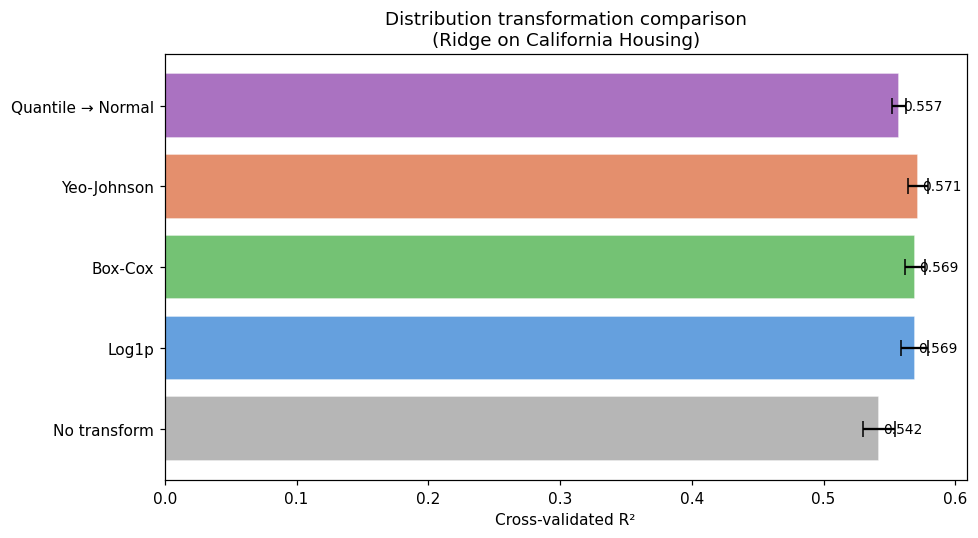

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = ['#aaaaaa', '#4a90d9', '#5cb85c', '#e07b54', '#9b59b6']

bars = ax.barh(names, means, xerr=stds, capsize=5,
               color=colors, edgecolor='white', alpha=0.85)
ax.set_xlabel('Cross-validated R²')
ax.set_title('Distribution transformation comparison\n(Ridge on California Housing)')
for bar, m in zip(bars, means):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{m:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **Diagnose before transforming** — compute skewness and draw Q-Q plots; don't transform symmetric features.
2. **Log transform** is the go-to for strictly positive right-skewed data; use `log1p` defensively to handle zeros.
3. **Box-Cox** automatically selects the optimal power but requires strictly positive input.
4. **Yeo-Johnson** is Box-Cox's safer sibling — use it by default; it handles zeros and negatives.
5. **Quantile transformation** guarantees Gaussianity at the cost of discarding exact value information — use as a last resort or when outlier robustness is paramount.
6. **Impact varies by algorithm** — tree models are unaffected by monotonic transforms; linear models and PCA benefit most.
7. **Wrap transforms in a Pipeline** — ensures the transform is fit on training data and the inverse can be applied to predictions.

---
## Exercises

1. Load the `seaborn` `diamonds` dataset. Check the skewness of `price`, `carat`, and `depth`. Which need transformation?
2. Apply Yeo-Johnson to all three columns inside a `Pipeline` with a `Ridge` regressor predicting `log(price)`. Compare R² with and without the transformation.
3. What happens when you apply `log1p` to a feature that is already approximately normal (e.g. `depth` in diamonds)? Plot the Q-Q plot before and after.
4. Implement a `SkewnessSelector` transformer that only applies `PowerTransformer` to columns whose `|skewness| > 0.5` and passes other columns through unchanged.

Diamonds dataset loaded. Shape: (53940, 10)
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75

Exercise 1: Skewness of price, carat, depth
price      skewness = +1.6184
carat      skewness = +1.1166
depth      skewness = -0.0823

Interpretation: price and carat are highly right-skewed (>1).
Depth is nearly symmetric (skewness near 0).
Thus price and carat need transformation; depth may not need any.

Exercise 2: Yeo-Johnson transformation vs no transformation
Predict log(price) using Ridge, with and without Yeo-Johnson on features
No transformation: R² = 0.8472 ± 0.0041
Yeo-Johnson on features: R² = 0.9359 ± 0.0012



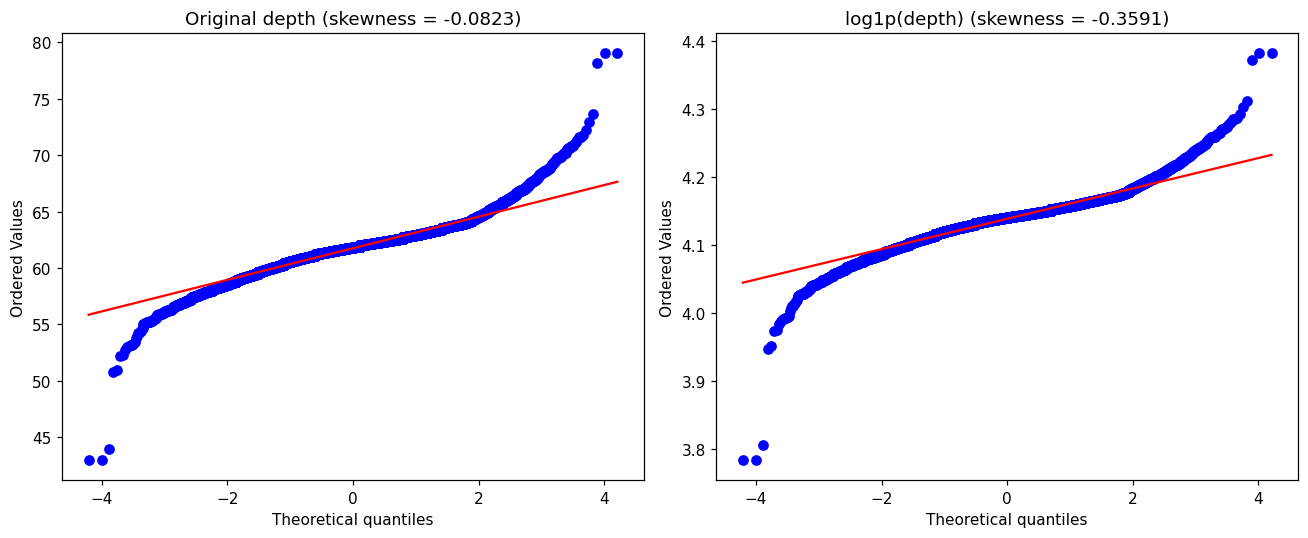

Observation: log1p on an already symmetric distribution introduces negative skewness
and worsens normality. Only transform features that are truly right-skewed.

Exercise 4: SkewnessSelector – applies PowerTransformer only if |skewness| > 0.5
Columns selected for transformation: ['carat']

Skewness before vs after:
carat      +1.1609 → +0.1282
depth      +0.0850 → +0.0850

Note: SkewnessSelector passes columns with |skewness| ≤ 0.5 unchanged,
and applies Yeo-Johnson to the rest. This avoids unnecessary transformations.


In [14]:
# ========== Setup ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PowerTransformer, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings('ignore')

# Load diamonds dataset from local file
file_path = r'C:\Users\35111\Downloads\OneDrive_1_2026-5-26\diamonds.csv'
diamonds = pd.read_csv(file_path)
print("Diamonds dataset loaded. Shape:", diamonds.shape)
print(diamonds.head())

# ========== Exercise 1: Check skewness of price, carat, depth ==========
print("\n" + "="*60)
print("Exercise 1: Skewness of price, carat, depth")
print("="*60)

features = ['price', 'carat', 'depth']
for col in features:
    skew_val = diamonds[col].skew()
    print(f"{col:10s} skewness = {skew_val:+.4f}")

# Interpretation
print("\nInterpretation: price and carat are highly right-skewed (>1).")
print("Depth is nearly symmetric (skewness near 0).")
print("Thus price and carat need transformation; depth may not need any.")

# ========== Exercise 2: Yeo-Johnson transformation + Ridge regression ==========
print("\n" + "="*60)
print("Exercise 2: Yeo-Johnson transformation vs no transformation")
print("Predict log(price) using Ridge, with and without Yeo-Johnson on features")
print("="*60)

# Prepare data
X = diamonds[['carat', 'depth']].copy()   # use only carat and depth for simplicity
y = np.log1p(diamonds['price'])            # log transform target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline without transformation
pipe_no_trans = Pipeline([
    ('model', Ridge(alpha=1.0))
])

# Pipeline with Yeo-Johnson transformation on features
pipe_yj = Pipeline([
    ('yj', PowerTransformer(method='yeo-johnson')),  # works on all features
    ('model', Ridge(alpha=1.0))
])

# Cross-validation scores
cv_no = cross_val_score(pipe_no_trans, X_train, y_train, cv=5, scoring='r2')
cv_yj = cross_val_score(pipe_yj, X_train, y_train, cv=5, scoring='r2')

print(f"No transformation: R² = {cv_no.mean():.4f} ± {cv_no.std():.4f}")
print(f"Yeo-Johnson on features: R² = {cv_yj.mean():.4f} ± {cv_yj.std():.4f}")

# ========== Exercise 3: Apply log1p to depth (already symmetric) and compare Q-Q plots ==========
print("\n" + "="*60)
print("Exercise 3: Apply log1p to depth (approx normal) and compare Q-Q plots")
print("="*60)

depth = diamonds['depth']
depth_log1p = np.log1p(depth)

# Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original depth
stats.probplot(depth, dist='norm', plot=axes[0])
axes[0].set_title(f'Original depth (skewness = {depth.skew():.4f})')

# log1p transformed
stats.probplot(depth_log1p, dist='norm', plot=axes[1])
axes[1].set_title(f'log1p(depth) (skewness = {depth_log1p.skew():.4f})')

plt.tight_layout()
plt.show()

print("Observation: log1p on an already symmetric distribution introduces negative skewness")
print("and worsens normality. Only transform features that are truly right-skewed.")

# ========== Exercise 4: Custom SkewnessSelector transformer ==========
print("\n" + "="*60)
print("Exercise 4: SkewnessSelector – applies PowerTransformer only if |skewness| > 0.5")
print("="*60)

class SkewnessSelector(BaseEstimator, TransformerMixin):
    """Apply Yeo-Johnson only to columns with absolute skewness > threshold."""
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.cols_to_transform_ = None
        self.transformer_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        skews = X.apply(lambda x: x.skew())
        self.cols_to_transform_ = skews[abs(skews) > self.threshold].index.tolist()
        if len(self.cols_to_transform_) > 0:
            self.transformer_ = PowerTransformer(method='yeo-johnson')
            self.transformer_.fit(X[self.cols_to_transform_])
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        if len(self.cols_to_transform_) > 0:
            X_transformed = self.transformer_.transform(X[self.cols_to_transform_])
            X[self.cols_to_transform_] = X_transformed
        return X.values

# Demonstrate on a small dataset
demo = diamonds[['carat', 'depth']].sample(5000, random_state=42)
selector = SkewnessSelector(threshold=0.5)
selector.fit(demo)
print(f"Columns selected for transformation: {selector.cols_to_transform_}")

# Transform and show skewness before/after
demo_transformed = selector.transform(demo)
demo_df_trans = pd.DataFrame(demo_transformed, columns=demo.columns)
print("\nSkewness before vs after:")
for col in demo.columns:
    before = demo[col].skew()
    after = demo_df_trans[col].skew()
    print(f"{col:10s} {before:+.4f} → {after:+.4f}")

# Final note
print("\nNote: SkewnessSelector passes columns with |skewness| ≤ 0.5 unchanged,")
print("and applies Yeo-Johnson to the rest. This avoids unnecessary transformations.")